# Import libraries

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset

In [6]:
house_prediction=pd.read_csv(r"C:\Users\Yatish Agarwal\Downloads\train (1).csv")
house_prediction

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [7]:
house_prediction.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# see how many null values are there 

In [8]:
house_prediction.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

# Check the count of different data types in the dataset

In [9]:
print(house_prediction.dtypes.value_counts())

str        43
int64      35
float64     3
Name: count, dtype: int64


# seperate the numerical values

In [10]:
numerical_prediction=house_prediction.select_dtypes(include=['int', 'float'])

In [11]:
numerical_prediction.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


# seperate the categorical values

In [12]:
categorical_values=house_prediction.select_dtypes(include=['str','object','category'])

In [13]:
categorical_values.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


# print the numerical columns

In [14]:
print("   numerical values    ")
numerical_prediction.columns

   numerical values    


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

# print categorical columns

In [15]:
print("    categorical values   ")
categorical_values.columns

    categorical values   


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

# Calculating median of all the numerical columns

In [16]:
numerical_medians = numerical_prediction.median()
numerical_medians

Id                  730.5
MSSubClass           50.0
LotFrontage          69.0
LotArea            9478.5
OverallQual           6.0
OverallCond           5.0
YearBuilt          1973.0
YearRemodAdd       1994.0
MasVnrArea            0.0
BsmtFinSF1          383.5
BsmtFinSF2            0.0
BsmtUnfSF           477.5
TotalBsmtSF         991.5
1stFlrSF           1087.0
2ndFlrSF              0.0
LowQualFinSF          0.0
GrLivArea          1464.0
BsmtFullBath          0.0
BsmtHalfBath          0.0
FullBath              2.0
HalfBath              0.0
BedroomAbvGr          3.0
KitchenAbvGr          1.0
TotRmsAbvGrd          6.0
Fireplaces            1.0
GarageYrBlt        1980.0
GarageCars            2.0
GarageArea          480.0
WoodDeckSF            0.0
OpenPorchSF          25.0
EnclosedPorch         0.0
3SsnPorch             0.0
ScreenPorch           0.0
PoolArea              0.0
MiscVal               0.0
MoSold                6.0
YrSold             2008.0
SalePrice        163000.0
dtype: float

# calculate the mode for categorical columns

In [17]:
categorical_modes = categorical_values.mode().iloc[0]
categorical_modes

MSZoning              RL
Street              Pave
Alley               Grvl
LotShape             Reg
LandContour          Lvl
Utilities         AllPub
LotConfig         Inside
LandSlope            Gtl
Neighborhood       NAmes
Condition1          Norm
Condition2          Norm
BldgType            1Fam
HouseStyle        1Story
RoofStyle          Gable
RoofMatl         CompShg
Exterior1st      VinylSd
Exterior2nd      VinylSd
MasVnrType       BrkFace
ExterQual             TA
ExterCond             TA
Foundation         PConc
BsmtQual              TA
BsmtCond              TA
BsmtExposure          No
BsmtFinType1         Unf
BsmtFinType2         Unf
Heating             GasA
HeatingQC             Ex
CentralAir             Y
Electrical         SBrkr
KitchenQual           TA
Functional           Typ
FireplaceQu           Gd
GarageType        Attchd
GarageFinish         Unf
GarageQual            TA
GarageCond            TA
PavedDrive             Y
PoolQC                Gd
Fence              MnPrv


# Put median of numerical columns in place of null values

In [18]:
numerical_prediction = numerical_prediction.replace(np.nan, numerical_prediction.median())
print("Remaining null values in numerical columns:", numerical_prediction.isnull().sum().sum())

Remaining null values in numerical columns: 0


# Put mode for categorical columns in place of null values

In [19]:
categorical_values = categorical_values.replace(np.nan, categorical_modes)
print("Remaining null values in categorical columns:", categorical_values.isnull().sum().sum())

Remaining null values in categorical columns: 0


# Add the two data sets together

In [20]:
house_prediction_cleaned = pd.concat([numerical_prediction, categorical_values], axis=1)
print("New DataFrame Shape:", house_prediction_cleaned.shape)
print("Total remaining null values:", house_prediction_cleaned.isnull().sum().sum())

New DataFrame Shape: (1460, 81)
Total remaining null values: 0


# Use One Hot Encoding in categorical columns

In [21]:
house_prediction_encoded = pd.get_dummies(house_prediction_cleaned, drop_first=True)
print("Shape after encoding:", house_prediction_encoded.shape)

Shape after encoding: (1460, 246)


# Feature scaling

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

# Scale only the numerical columns (excluding the target 'SalePrice' and 'Id')

In [24]:
scale_cols = [col for col in numerical_prediction.columns if col not in ['Id', 'SalePrice']]

house_prediction_encoded[scale_cols] = scaler.fit_transform(house_prediction_encoded[scale_cols])
house_prediction_encoded

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.073375,-0.220875,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,...,False,False,False,False,True,False,False,False,True,False
1,2,-0.872563,0.460320,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,...,False,False,False,False,True,False,False,False,True,False
2,3,0.073375,-0.084636,0.073480,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,...,False,False,False,False,True,False,False,False,True,False
3,4,0.309859,-0.447940,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,...,False,False,False,False,True,False,False,False,False,False
4,5,0.073375,0.641972,0.375148,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,0.073375,-0.357114,-0.260560,-0.071836,-0.517200,0.918511,0.733308,-0.570750,-0.973018,...,False,False,False,False,True,False,False,False,True,False
1456,1457,-0.872563,0.687385,0.266407,-0.071836,0.381743,0.222975,0.151865,0.087911,0.759659,...,False,False,False,False,True,False,False,False,True,False
1457,1458,0.309859,-0.175462,-0.147810,0.651479,3.078570,-1.002492,1.024029,-0.570750,-0.369871,...,False,False,False,False,True,False,False,False,True,False
1458,1459,-0.872563,-0.084636,-0.080160,-0.795151,0.381743,-0.704406,0.539493,-0.570750,-0.865548,...,False,False,False,False,True,False,False,False,True,False


# We need to split the dataset for traning

In [25]:
from sklearn.model_selection import train_test_split

X = house_prediction_encoded.drop(columns=['Id', 'SalePrice'])
y = house_prediction_encoded['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train 80% data and test 20% 

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 51392.66


In [28]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on your 80% training data
rf_model.fit(X_train, y_train)

# 3. Predict on your 20% validation data
rf_preds = rf_model.predict(X_val)

# 4. Calculate the new RMSE
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
print(f"Random Forest Validation RMSE: {rf_rmse:.2f}")

Random Forest Validation RMSE: 28918.64


# Get feature importances from the model

C:\Users\Yatish Agarwal\AppData\Local\Temp\ipykernel_3684\3757946822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=forest_importances.head(10), y=forest_importances.head(10).index, palette="viridis")


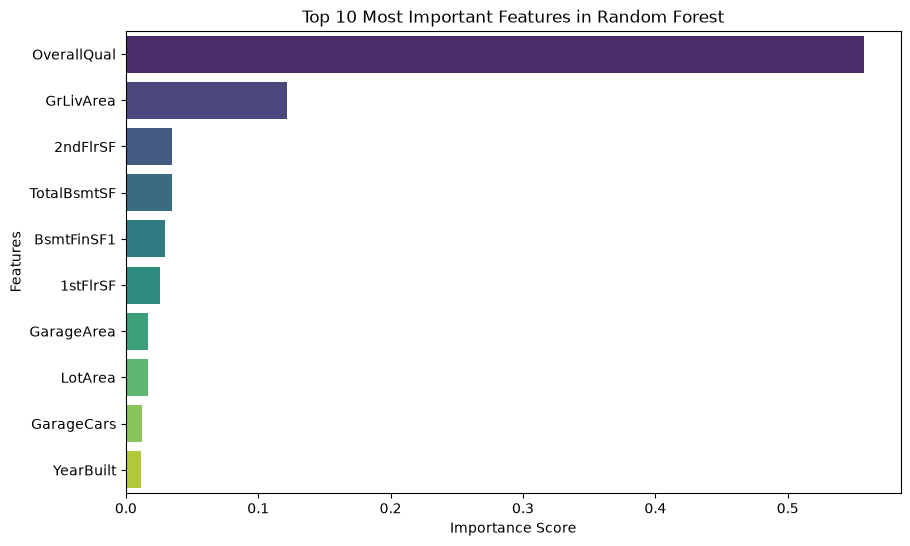

In [29]:
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a Series and sort it
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances.head(10), y=forest_importances.head(10).index, palette="viridis")
plt.title("Top 10 Most Important Features in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Plot Actual vs. Predicted Prices (Scatter Plot)

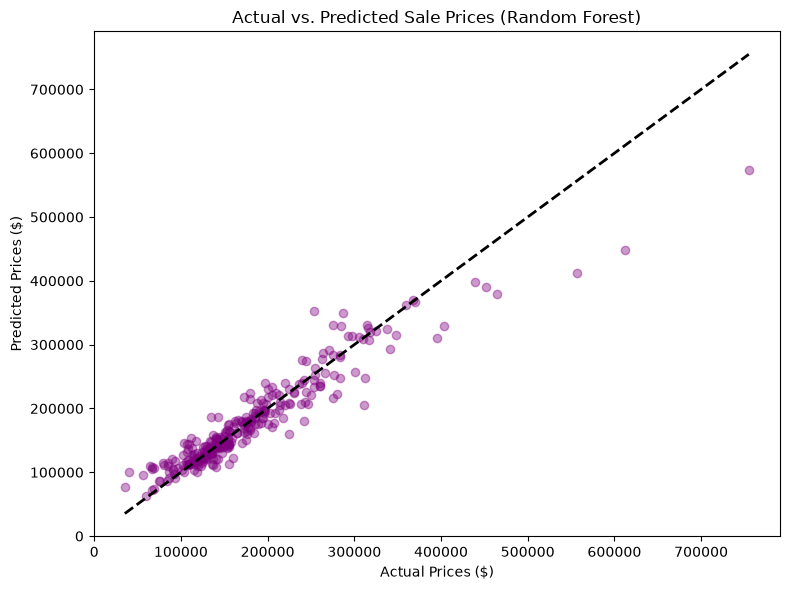

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, rf_preds, alpha=0.4, color='purple')
# Draw a diagonal line representing a perfect 1-to-1 prediction
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2) 

plt.title("Actual vs. Predicted Sale Prices (Random Forest)")
plt.xlabel("Actual Prices ($)")
plt.ylabel("Predicted Prices ($)")
plt.tight_layout()
plt.show()

# The Regression Version of a Confusion Matrix: Residual Plot

In [31]:
# Calculate residuals
residuals = y_val - rf_preds

plt.figure(figsize=(8, 5))
plt.axhline(0, color='red', linestyle='--')
plt.scatter(rf_preds, residuals, alpha=0.4, color='teal')
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Predicted Prices ($)")
plt.ylabel("Residuals (Errors) ($)")
plt.show()

In [ ]:
from sklearn.metrics import r2_score

rf_r2 = r2_score(y_val, rf_preds)
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest R2 Score: 0.8910
